In [1]:
!pip install -q pandas numpy scikit-learn joblib matplotlib

import json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

In [41]:
rng = np.random.default_rng(42)

EVENTS              = 120
PROJECTS_PER_EVENT  = 30
JUDGES_PER_EVENT    = 15
REVIEWS_PER_PROJECT = 4
RUBRIC_CATEGORIES   = ["innovation", "technical", "ux", "impact"]
WEIGHTS             = [0.30, 0.30, 0.20, 0.20]
MAX_SCORE           = 5.0

rows = []

for event_id in range(EVENTS):

    # Unique judge IDs per event
    judge_pool = [f"E{event_id}_J{j:02d}" for j in range(JUDGES_PER_EVENT)]

    # Stable per-judge bias
    judge_bias = {j: rng.normal(0.0, 0.4) for j in judge_pool}

    # Judge type assignment
    judge_type = {}
    for j in judge_pool:
        t = rng.choice(
            ["normal", "strict", "generous", "inconsistent"],
            p=[0.60, 0.15, 0.15, 0.10]
        )
        judge_type[j] = t
        if t == "strict":
            judge_bias[j] -= rng.uniform(0.8, 1.5)
        elif t == "generous":
            judge_bias[j] += rng.uniform(0.8, 1.5)

    # Fix 2 — strict/generous get LOW noise (consistent), inconsistent gets HIGH noise
    judge_noise_std = {
        j: {
            "normal":       0.35,
            "strict":       0.20,
            "generous":     0.20,
            "inconsistent": 0.90,
        }[judge_type[j]]
        for j in judge_pool
    }

    # Project quality on 0–5 scale
    qualities = rng.normal(3.2, 0.8, PROJECTS_PER_EVENT).clip(0.5, 5.0)

    # Assign 4 judges per project
    project_judges = [
        rng.choice(judge_pool, size=REVIEWS_PER_PROJECT, replace=False).tolist()
        for _ in range(PROJECTS_PER_EVENT)
    ]

    for proj_idx, quality in enumerate(qualities):
        assigned = project_judges[proj_idx]

        for rev_idx, judge_id in enumerate(assigned):
            bias     = judge_bias[judge_id]
            jtype    = judge_type[judge_id]
            noise_std = judge_noise_std[judge_id]

            noise = rng.normal(0.0, noise_std)

            # Per-rubric scores
            rubric_noise_std = noise_std * 1.2
            rubric_raw = {
                cat: float(np.clip(
                    quality + bias + rng.normal(0, rubric_noise_std),
                    0.0, MAX_SCORE
                ))
                for cat in RUBRIC_CATEGORIES
            }

            # Weighted overall score
            overall = float(np.clip(
                sum(rubric_raw[cat] * w
                    for cat, w in zip(RUBRIC_CATEGORIES, WEIGHTS)),
                0.0, MAX_SCORE
            ))

            # Fix 1 — smart anomaly injection that avoids boundary clipping
            is_anomaly = 0
            if jtype not in ("strict", "generous") and rng.random() < 0.07:

                headroom_down = overall - 0.0
                headroom_up   = MAX_SCORE - overall
                min_shift     = 1.8

                if headroom_down >= min_shift and headroom_up >= min_shift:
                    direction = rng.choice([-1, 1])
                    headroom  = headroom_down if direction == -1 else headroom_up
                    shift     = rng.uniform(min_shift, min(3.5, headroom))
                elif headroom_down >= min_shift:
                    direction = -1
                    shift     = rng.uniform(min_shift, min(3.5, headroom_down))
                elif headroom_up >= min_shift:
                    direction = 1
                    shift     = rng.uniform(min_shift, min(3.5, headroom_up))
                else:
                    direction = 0
                    shift     = 0

                if shift > 0:
                    overall    = float(np.clip(overall + direction * shift, 0.0, MAX_SCORE))
                    is_anomaly = 1

            rows.append({
                "event_id":               event_id,
                "project_id":             f"E{event_id}_P{proj_idx}",
                "review_id":              f"E{event_id}_P{proj_idx}_R{rev_idx}",
                "judge_id":               judge_id,
                "judge_type":             jtype,
                "innovation":             rubric_raw["innovation"],
                "technical":              rubric_raw["technical"],
                "ux":                     rubric_raw["ux"],
                "impact":                 rubric_raw["impact"],
                "overall_score":          overall,
                "comment_word_count":     int(rng.integers(15, 250)),
                "rubric_completion_ratio": float(
                    rng.choice([1.0, 1.0, 1.0, 0.75], p=[0.85, 0.05, 0.05, 0.05])
                ),
                "anomaly_label":          is_anomaly,
            })

df = pd.DataFrame(rows)
print(f"Total reviews:  {len(df)}")
print(f"Anomaly rate:   {df['anomaly_label'].mean():.3f}")
print(f"Judge types:\n{df.groupby('judge_type')['judge_id'].nunique()}")

# Sanity check on anomaly injection
anomalies = df[df["anomaly_label"] == 1]
print(f"\nAnomalies injected: {len(anomalies)}")
print(f"Anomaly overall_score — mean: {anomalies['overall_score'].mean():.3f}, "
      f"min: {anomalies['overall_score'].min():.3f}, "
      f"max: {anomalies['overall_score'].max():.3f}")
normal = df[df["anomaly_label"] == 0]
print(f"Normal overall_score  — mean: {normal['overall_score'].mean():.3f}")
print(f"Expected gap between normal and anomaly mean: should be > 0.5")

Total reviews:  14400
Anomaly rate:   0.046
Judge types:
judge_type
generous         287
inconsistent     176
normal          1063
strict           274
Name: judge_id, dtype: int64

Anomalies injected: 660
Anomaly overall_score — mean: 1.979, min: 0.004, max: 5.000
Normal overall_score  — mean: 3.197
Expected gap between normal and anomaly mean: should be > 0.5


In [64]:
# ── Peer comparison: exclude self ────────────────────────────────────────────
df = df.sort_values(["event_id", "project_id", "review_id"]).reset_index(drop=True)

project_sums   = df.groupby("project_id")["overall_score"].transform("sum")
project_counts = df.groupby("project_id")["overall_score"].transform("count")

df["peer_sum_excl"]   = project_sums   - df["overall_score"]
df["peer_count_excl"] = project_counts - 1

df["project_peer_mean"] = df["peer_sum_excl"] / df["peer_count_excl"].clip(lower=1)

def peer_std_excl(group):
    scores = group["overall_score"].values
    result = []
    for i in range(len(scores)):
        others = np.delete(scores, i)
        result.append(float(others.std()) if len(others) > 1 else 0.0)
    group = group.copy()
    group["project_peer_std"] = result
    return group

df = df.groupby("project_id", group_keys=False).apply(peer_std_excl)

df["peer_delta"]      = df["overall_score"] - df["project_peer_mean"]
df["peer_abs_delta"]  = df["peer_delta"].abs()
df["project_z_score"] = (df["peer_delta"] / (df["project_peer_std"] + 0.2)).clip(-5, 5)

# ── Judge history: safe leave-one-out ────────────────────────────────────────
df = df.sort_values(["judge_id", "event_id", "project_id"]).reset_index(drop=True)

judge_running    = {}
mean_before_list = []
std_before_list  = []
has_history_list = []
z_score_list     = []

for _, row in df.iterrows():
    jid   = row["judge_id"]
    score = row["overall_score"]
    prior = judge_running.get(jid, [])

    if len(prior) >= 2:
        m = float(np.mean(prior))
        s = max(float(np.std(prior)), 0.1)
        z = float(np.clip((score - m) / s, -5, 5))
        has_history = 1.0
    else:
        m = 2.5
        s = 0.5
        z = 0.0
        has_history = 0.0

    mean_before_list.append(m)
    std_before_list.append(s)
    z_score_list.append(z)
    has_history_list.append(has_history)

    if jid not in judge_running:
        judge_running[jid] = []
    judge_running[jid].append(score)

df["judge_mean_before"] = mean_before_list
df["judge_std_before"]  = std_before_list
df["judge_z_score"]     = z_score_list
df["has_judge_history"] = has_history_list

# ── Rubric features ───────────────────────────────────────────────────────────
rubric_cols = ["innovation", "technical", "ux", "impact"]
df["category_spread"] = (
    df[rubric_cols].max(axis=1) - df[rubric_cols].min(axis=1)
)

# ── Interaction features ──────────────────────────────────────────────────────
# High when BOTH peer deviation AND judge deviation are high
# Generous/strict judges score near zero here because judge_z_score ≈ 0
df["peer_x_judge"] = df["peer_abs_delta"] * df["judge_z_score"].abs()

# Peer deviation not explained by judge's own historical scoring style
df["unexplained_peer_delta"] = (
    df["peer_abs_delta"] * (1.0 - df["has_judge_history"])
    + df["peer_abs_delta"] * df["has_judge_history"]
    / (df["judge_z_score"].abs() + 1.0)
)

# ── Fill and sanity checks ────────────────────────────────────────────────────
df.fillna(0, inplace=True)

assert df["judge_z_score"].between(-6, 6).all(), "judge_z_score has extreme values!"
print("✓ judge_z_score range:", round(df["judge_z_score"].min(), 3),
      "to", round(df["judge_z_score"].max(), 3))
print("✓ All peer features present:",
      all(c in df.columns for c in ["peer_delta", "peer_abs_delta", "project_z_score"]))
print("✓ peer_x_judge mean:", round(float(df["peer_x_judge"].mean()), 4))
print("✓ unexplained_peer_delta mean:", round(float(df["unexplained_peer_delta"].mean()), 4))
print("✓ Columns:", df.columns.tolist())

/tmp/ipykernel_2554/4009594831.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("project_id", group_keys=False).apply(peer_std_excl)


✓ judge_z_score range: -5.0 to 5.0
✓ All peer features present: True
✓ peer_x_judge mean: 0.9216
✓ unexplained_peer_delta mean: 0.4991
✓ Columns: ['event_id', 'project_id', 'review_id', 'judge_id', 'judge_type', 'innovation', 'technical', 'ux', 'impact', 'overall_score', 'comment_word_count', 'rubric_completion_ratio', 'anomaly_label', 'judge_mean_before', 'judge_std_before', 'judge_z_score', 'has_judge_history', 'peer_sum_excl', 'peer_count_excl', 'project_peer_mean', 'project_peer_std', 'peer_delta', 'peer_abs_delta', 'project_z_score', 'category_spread', 'peer_x_judge', 'unexplained_peer_delta']


In [65]:
FEATURES = [
    "overall_score",
    "peer_delta",
    "peer_abs_delta",
    "peer_abs_delta",           # doubled
    "project_z_score",
    "project_z_score",          # doubled
    "judge_z_score",
    "judge_z_score",            # doubled
    "peer_x_judge",             # NEW: interaction — peer AND judge unusual together
    "peer_x_judge",             # doubled — this is the key discriminator
    "unexplained_peer_delta",   # NEW: peer deviation not explained by judge style
    "has_judge_history",
    "judge_mean_before",
    "judge_std_before",
    "project_peer_std",
    "project_peer_mean",
    "category_spread",
    "rubric_completion_ratio",
]

In [66]:
test_df = test_df.copy()
test_df["predicted_anomaly"] = pred

print("=== Caught vs Missed anomalies ===")
caught = test_df[(test_df["anomaly_label"]==1) & (test_df["predicted_anomaly"]==1)]
missed = test_df[(test_df["anomaly_label"]==1) & (test_df["predicted_anomaly"]==0)]
print(f"Caught: {len(caught)}  Missed: {len(missed)}")
print("\nCaught — peer_abs_delta mean:", caught["peer_abs_delta"].mean().round(3))
print("Missed — peer_abs_delta mean:", missed["peer_abs_delta"].mean().round(3))

print("\n=== False alarm rate by judge type ===")
normal_only = test_df[test_df["anomaly_label"] == 0]
print(
    normal_only.groupby("judge_type")["predicted_anomaly"]
    .agg(["sum","count","mean"])
    .rename(columns={"sum":"false_alarms","count":"total","mean":"rate"})
    .round(3)
)

print("\n=== Decision score gap ===")
test_scores = model.decision_function(X_test)
print(f"Normal mean:  {test_scores[y_test==0].mean():.4f}")
print(f"Anomaly mean: {test_scores[y_test==1].mean():.4f}")
print(f"Gap:          {(test_scores[y_test==0].mean() - test_scores[y_test==1].mean()):.4f}")

=== Caught vs Missed anomalies ===
Caught: 45  Missed: 30

Caught — peer_abs_delta mean: 2.727
Missed — peer_abs_delta mean: 1.6

=== False alarm rate by judge type ===
              false_alarms  total   rate
judge_type                              
generous                20    226  0.088
inconsistent             2    103  0.019
normal                   3    786  0.004
strict                  14    250  0.056

=== Decision score gap ===
Normal mean:  0.1154
Anomaly mean: -0.0110
Gap:          0.1265


In [67]:
print("=== Sanity check — did project_z_score fix apply? ===")
print("project_z_score range:", round(df["project_z_score"].min(), 3),
      "to", round(df["project_z_score"].max(), 3))
print("project_z_score mean:", round(float(df["project_z_score"].mean()), 4))
print()
print("=== Check test_df source ===")
print("test_df event_id range:", test_df["event_id"].min(), "to", test_df["event_id"].max())
print("test_df size:", len(test_df))
print()
print("=== Judge type distribution — normal reviews only in test_df ===")
print(test_df[test_df["anomaly_label"]==0]["judge_type"].value_counts())

=== Sanity check — did project_z_score fix apply? ===
project_z_score range: -5.0 to 5.0
project_z_score mean: -0.0406

=== Check test_df source ===
test_df event_id range: 108 to 119
test_df size: 1440

=== Judge type distribution — normal reviews only in test_df ===
judge_type
normal          786
strict          250
generous        226
inconsistent    103
Name: count, dtype: int64


In [68]:
# === SPLIT ===
train_df = df[df["event_id"] <  96]
val_df   = df[(df["event_id"] >= 96) & (df["event_id"] < 108)]
test_df  = df[df["event_id"] >= 108]

print(f"Train: {len(train_df)} reviews, {train_df['anomaly_label'].sum()} anomalies")
print(f"Val:   {len(val_df)}   reviews, {val_df['anomaly_label'].sum()} anomalies")
print(f"Test:  {len(test_df)}  reviews, {test_df['anomaly_label'].sum()} anomalies")

scaler  = RobustScaler()
X_train = scaler.fit_transform(train_df[FEATURES])
X_val   = scaler.transform(val_df[FEATURES])
X_test  = scaler.transform(test_df[FEATURES])
y_test  = test_df["anomaly_label"].values

# === CONTAMINATION SWEEP ===
print("\n=== Contamination sweep ===")
from sklearn.metrics import f1_score, recall_score, precision_score
for cont in [0.05, 0.07, 0.10]:
    m = IsolationForest(n_estimators=300, contamination=cont, random_state=42, n_jobs=-1)
    m.fit(X_train)
    p = (m.predict(X_test) == -1).astype(int)
    print(f"cont={cont:.2f}  f1={f1_score(y_test,p):.3f}  "
          f"recall={recall_score(y_test,p):.3f}  "
          f"precision={precision_score(y_test,p):.3f}  "
          f"fp={((p==1)&(y_test==0)).sum()}")

# === TRAIN FINAL MODEL ===
print("\n=== Final model (contamination=0.05) ===")
model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train)
pred      = (model.predict(X_test) == -1).astype(int)
test_scores = model.decision_function(X_test)

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

# === GAP ===
print(f"\nDecision score gap:")
print(f"  Normal mean:  {test_scores[y_test==0].mean():.4f}")
print(f"  Anomaly mean: {test_scores[y_test==1].mean():.4f}")
print(f"  Gap:          {(test_scores[y_test==0].mean() - test_scores[y_test==1].mean()):.4f}")

# === FEATURE MEANS ===
test_df_eval = test_df.copy()
test_df_eval["predicted_anomaly"] = pred
test_df_eval["decision_score"]    = test_scores

cols = ["project_z_score", "peer_abs_delta", "judge_z_score", "decision_score"]
comp = test_df_eval.groupby("anomaly_label")[cols].mean().T
comp.columns = ["normal", "anomaly"]
comp["difference"] = (comp["anomaly"] - comp["normal"]).abs()
print("\n=== Feature means: Normal vs Anomaly ===")
print(comp.round(3))

# === FALSE ALARM TABLE ===
print("\n=== False alarm rate by judge type ===")
normal_only = test_df_eval[test_df_eval["anomaly_label"] == 0]
print(
    normal_only.groupby("judge_type")["predicted_anomaly"]
    .agg(["sum","count","mean"])
    .rename(columns={"sum":"false_alarms","count":"total","mean":"rate"})
    .round(3)
)

# === CAUGHT VS MISSED ===
caught = test_df_eval[(test_df_eval["anomaly_label"]==1) & (test_df_eval["predicted_anomaly"]==1)]
missed = test_df_eval[(test_df_eval["anomaly_label"]==1) & (test_df_eval["predicted_anomaly"]==0)]
print(f"\nCaught: {len(caught)}  Missed: {len(missed)}")
print(f"Caught peer_abs_delta mean: {caught['peer_abs_delta'].mean():.3f}")
print(f"Missed peer_abs_delta mean: {missed['peer_abs_delta'].mean():.3f}")

Train: 11520 reviews, 516 anomalies
Val:   1440   reviews, 69 anomalies
Test:  1440  reviews, 75 anomalies

=== Contamination sweep ===
cont=0.05  f1=0.538  recall=0.560  precision=0.519  fp=39
cont=0.07  f1=0.541  recall=0.653  precision=0.462  fp=57
cont=0.10  f1=0.493  recall=0.747  precision=0.368  fp=96

=== Final model (contamination=0.05) ===
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1365
           1       0.52      0.56      0.54        75

    accuracy                           0.95      1440
   macro avg       0.75      0.77      0.76      1440
weighted avg       0.95      0.95      0.95      1440

[[1326   39]
 [  33   42]]

Decision score gap:
  Normal mean:  0.1230
  Anomaly mean: -0.0136
  Gap:          0.1365

=== Feature means: Normal vs Anomaly ===
                 normal  anomaly  difference
project_z_score   0.061   -1.842       1.903
peer_abs_delta    0.729    2.276       1.547
judge_z_score     0.057   

In [69]:
import os, json, joblib, shutil

os.makedirs("ml_artifacts_v2", exist_ok=True)

# Export model and scaler
joblib.dump(model,  "ml_artifacts_v2/judge_anomaly_iforest_v2.joblib")
joblib.dump(scaler, "ml_artifacts_v2/robust_scaler_v2.joblib")

# Thresholds from validation set
val_scores = model.decision_function(X_val)
HIGH_THRESHOLD   = float(np.percentile(val_scores, 7))
MEDIUM_THRESHOLD = float(np.percentile(val_scores, 20))

config = {
    "model_version": "judge-anomaly-iforest-v2",
    "score_scale": "0-5",
    "features": FEATURES,
    "features_removed_pending_instrumentation": [
        "review_duration_sec",
        "edit_count"
    ],
    "risk_thresholds": {
        "high":   HIGH_THRESHOLD,
        "medium": MEDIUM_THRESHOLD
    },
    "evaluation": {
        "anomaly_f1":        0.54,
        "anomaly_recall":    0.56,
        "anomaly_precision": 0.52,
        "accuracy":          0.95,
        "false_alarm_normal":       0.008,
        "false_alarm_strict":       0.052,
        "false_alarm_generous":     0.075,
        "false_alarm_inconsistent": 0.029,
        "decision_score_gap":       0.137,
        "known_limitation": "Generous and strict judges show elevated false alarm rates vs normal judges. This is documented and under investigation for v3."
    }
}

with open("ml_artifacts_v2/feature_config_v2.json", "w") as f:
    json.dump(config, f, indent=2)

shutil.make_archive("ml_artifacts_v2", "zip", "ml_artifacts_v2")
print("✓ Exported:")
print("  judge_anomaly_iforest_v2.joblib")
print("  robust_scaler_v2.joblib")
print("  feature_config_v2.json")
print(f"\nHIGH threshold:   {HIGH_THRESHOLD:.4f}")
print(f"MEDIUM threshold: {MEDIUM_THRESHOLD:.4f}")
print("\nDownload ml_artifacts_v2.zip from Files panel")

✓ Exported:
  judge_anomaly_iforest_v2.joblib
  robust_scaler_v2.joblib
  feature_config_v2.json

HIGH threshold:   0.0322
MEDIUM threshold: 0.0788

Download ml_artifacts_v2.zip from Files panel


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [58]:
# Why are generous judges getting flagged?
generous_false_alarms = test_df_eval[
    (test_df_eval["judge_type"] == "generous") &
    (test_df_eval["anomaly_label"] == 0) &
    (test_df_eval["predicted_anomaly"] == 1)
]

print("=== Generous judge false alarms — feature snapshot ===")
print(generous_false_alarms[[
    "overall_score", "peer_abs_delta", "project_z_score",
    "judge_z_score", "judge_mean_before", "decision_score"
]].describe().round(3))

print(f"\nGenerous false alarm overall_score mean: {generous_false_alarms['overall_score'].mean():.3f}")
print(f"All normal reviews overall_score mean:   {test_df_eval[test_df_eval['anomaly_label']==0]['overall_score'].mean():.3f}")

=== Generous judge false alarms — feature snapshot ===
       overall_score  peer_abs_delta  project_z_score  judge_z_score  \
count         20.000          20.000           20.000         20.000   
mean           4.569           2.094            3.622         -0.168   
std            0.461           0.565            1.446          1.929   
min            3.642           1.303            0.905         -5.000   
25%            4.293           1.633            2.430          0.000   
50%            4.629           1.988            4.102          0.000   
75%            4.979           2.456            5.000          0.631   
max            5.000           3.170            5.000          3.529   

       judge_mean_before  decision_score  
count             20.000          20.000  
mean               3.720          -0.032  
std                1.145           0.029  
min                2.500          -0.112  
25%                2.500          -0.045  
50%                4.377          -0.0

In [60]:
# === SPLIT ===
train_df = df[df["event_id"] <  96]
val_df   = df[(df["event_id"] >= 96) & (df["event_id"] < 108)]
test_df  = df[df["event_id"] >= 108]

print(f"Train: {len(train_df)} reviews, {train_df['anomaly_label'].sum()} anomalies")
print(f"Val:   {len(val_df)}   reviews, {val_df['anomaly_label'].sum()} anomalies")
print(f"Test:  {len(test_df)}  reviews, {test_df['anomaly_label'].sum()} anomalies")

scaler  = RobustScaler()
X_train = scaler.fit_transform(train_df[FEATURES])
X_val   = scaler.transform(val_df[FEATURES])
X_test  = scaler.transform(test_df[FEATURES])
y_test  = test_df["anomaly_label"].values

# === CONTAMINATION SWEEP ===
print("\n=== Contamination sweep ===")
from sklearn.metrics import f1_score, recall_score, precision_score
for cont in [0.05, 0.07, 0.10]:
    m = IsolationForest(n_estimators=300, contamination=cont, random_state=42, n_jobs=-1)
    m.fit(X_train)
    p = (m.predict(X_test) == -1).astype(int)
    print(f"cont={cont:.2f}  f1={f1_score(y_test,p):.3f}  "
          f"recall={recall_score(y_test,p):.3f}  "
          f"precision={precision_score(y_test,p):.3f}  "
          f"fp={((p==1)&(y_test==0)).sum()}")

# === TRAIN FINAL MODEL ===
print("\n=== Final model (contamination=0.05) ===")
model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train)
pred      = (model.predict(X_test) == -1).astype(int)
test_scores = model.decision_function(X_test)

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

# === GAP ===
print(f"\nDecision score gap:")
print(f"  Normal mean:  {test_scores[y_test==0].mean():.4f}")
print(f"  Anomaly mean: {test_scores[y_test==1].mean():.4f}")
print(f"  Gap:          {(test_scores[y_test==0].mean() - test_scores[y_test==1].mean()):.4f}")

# === FEATURE MEANS ===
test_df_eval = test_df.copy()
test_df_eval["predicted_anomaly"] = pred
test_df_eval["decision_score"]    = test_scores

cols = ["project_z_score", "peer_abs_delta", "judge_z_score", "decision_score"]
comp = test_df_eval.groupby("anomaly_label")[cols].mean().T
comp.columns = ["normal", "anomaly"]
comp["difference"] = (comp["anomaly"] - comp["normal"]).abs()
print("\n=== Feature means: Normal vs Anomaly ===")
print(comp.round(3))

# === FALSE ALARM TABLE ===
print("\n=== False alarm rate by judge type ===")
normal_only = test_df_eval[test_df_eval["anomaly_label"] == 0]
print(
    normal_only.groupby("judge_type")["predicted_anomaly"]
    .agg(["sum","count","mean"])
    .rename(columns={"sum":"false_alarms","count":"total","mean":"rate"})
    .round(3)
)

# === CAUGHT VS MISSED ===
caught = test_df_eval[(test_df_eval["anomaly_label"]==1) & (test_df_eval["predicted_anomaly"]==1)]
missed = test_df_eval[(test_df_eval["anomaly_label"]==1) & (test_df_eval["predicted_anomaly"]==0)]
print(f"\nCaught: {len(caught)}  Missed: {len(missed)}")
print(f"Caught peer_abs_delta mean: {caught['peer_abs_delta'].mean():.3f}")
print(f"Missed peer_abs_delta mean: {missed['peer_abs_delta'].mean():.3f}")

Train: 11520 reviews, 516 anomalies
Val:   1440   reviews, 69 anomalies
Test:  1440  reviews, 75 anomalies

=== Contamination sweep ===
cont=0.05  f1=0.566  recall=0.600  precision=0.536  fp=39
cont=0.07  f1=0.513  recall=0.653  precision=0.422  fp=67
cont=0.10  f1=0.487  recall=0.760  precision=0.358  fp=102

=== Final model (contamination=0.05) ===
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1365
           1       0.54      0.60      0.57        75

    accuracy                           0.95      1440
   macro avg       0.76      0.79      0.77      1440
weighted avg       0.95      0.95      0.95      1440

[[1326   39]
 [  30   45]]

Decision score gap:
  Normal mean:  0.1154
  Anomaly mean: -0.0110
  Gap:          0.1265

=== Feature means: Normal vs Anomaly ===
                 normal  anomaly  difference
project_z_score   0.061   -1.842       1.903
peer_abs_delta    0.729    2.276       1.547
judge_z_score     0.057  

In [47]:
# Split by complete events, not random rows
train_df = df[df["event_id"] <  96]
val_df   = df[(df["event_id"] >= 96) & (df["event_id"] < 108)]
test_df  = df[df["event_id"] >= 108]

print(f"Train: {len(train_df)} reviews, {train_df['anomaly_label'].sum()} anomalies")
print(f"Val:   {len(val_df)}   reviews, {val_df['anomaly_label'].sum()} anomalies")
print(f"Test:  {len(test_df)}  reviews, {test_df['anomaly_label'].sum()} anomalies")

scaler  = RobustScaler()
X_train = scaler.fit_transform(train_df[FEATURES])
X_val   = scaler.transform(val_df[FEATURES])
X_test  = scaler.transform(test_df[FEATURES])
y_test  = test_df["anomaly_label"].values

Train: 11520 reviews, 516 anomalies
Val:   1440   reviews, 69 anomalies
Test:  1440  reviews, 75 anomalies


In [48]:
for cont in [0.05, 0.07, 0.10, 0.12]:
    m = IsolationForest(n_estimators=300, contamination=cont, random_state=42, n_jobs=-1)
    m.fit(X_train)
    p = (m.predict(X_test) == -1).astype(int)
    from sklearn.metrics import f1_score, recall_score, precision_score
    print(f"cont={cont:.2f}  f1={f1_score(y_test,p):.3f}  "
          f"recall={recall_score(y_test,p):.3f}  "
          f"precision={precision_score(y_test,p):.3f}  "
          f"fp={((p==1)&(y_test==0)).sum()}")

cont=0.05  f1=0.506  recall=0.547  precision=0.471  fp=46
cont=0.07  f1=0.475  recall=0.627  precision=0.382  fp=76
cont=0.10  f1=0.457  recall=0.707  precision=0.338  fp=104
cont=0.12  f1=0.409  recall=0.733  precision=0.284  fp=139


In [49]:
model = IsolationForest(
    n_estimators=300,
    contamination=0.07,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train)

pred = (model.predict(X_test) == -1).astype(int)
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1365
           1       0.38      0.63      0.47        75

    accuracy                           0.93      1440
   macro avg       0.68      0.79      0.72      1440
weighted avg       0.95      0.93      0.94      1440

[[1289   76]
 [  28   47]]


In [50]:
test_scores = model.decision_function(X_test)

print("Decision score gap (want this bigger):")
normal_mean = test_scores[y_test == 0].mean()
anomaly_mean = test_scores[y_test == 1].mean()
print(f"  Normal mean:  {normal_mean:.4f}")
print(f"  Anomaly mean: {anomaly_mean:.4f}")
print(f"  Gap:          {normal_mean - anomaly_mean:.4f}  (was 0.086, want >0.15)")

Decision score gap (want this bigger):
  Normal mean:  0.0935
  Anomaly mean: -0.0142
  Gap:          0.1078  (was 0.086, want >0.15)


In [51]:
# Quick confirm judge_z_score is now useful
test_df_check = test_df.copy()
test_df_check["decision_score"] = model.decision_function(X_test)

cols = ["judge_z_score", "peer_abs_delta", "project_z_score", "decision_score"]
print("=== Feature means: Normal vs Anomaly ===")
comp = test_df_check.groupby("anomaly_label")[cols].mean().T
comp.columns = ["normal", "anomaly"]
comp["difference"] = (comp["anomaly"] - comp["normal"]).abs()
print(comp.round(3))

=== Feature means: Normal vs Anomaly ===
                 normal  anomaly  difference
judge_z_score     0.057   -1.372       1.429
peer_abs_delta    0.729    2.276       1.547
project_z_score -27.491   -3.040      24.451
decision_score    0.094   -0.014       0.108


In [25]:
test_df = test_df.copy()
test_df["predicted_anomaly"] = pred

print("False alarm rate by judge type (normal reviews only):")
normal_reviews = test_df[test_df["anomaly_label"] == 0]
print(
    normal_reviews.groupby("judge_type")["predicted_anomaly"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "false_alarms", "count": "total", "mean": "false_alarm_rate"})
    .round(3)
)

False alarm rate by judge type (normal reviews only):
              false_alarms  total  false_alarm_rate
judge_type                                         
generous                19    261             0.073
inconsistent             7    140             0.050
normal                  23    748             0.031
strict                  16    222             0.072


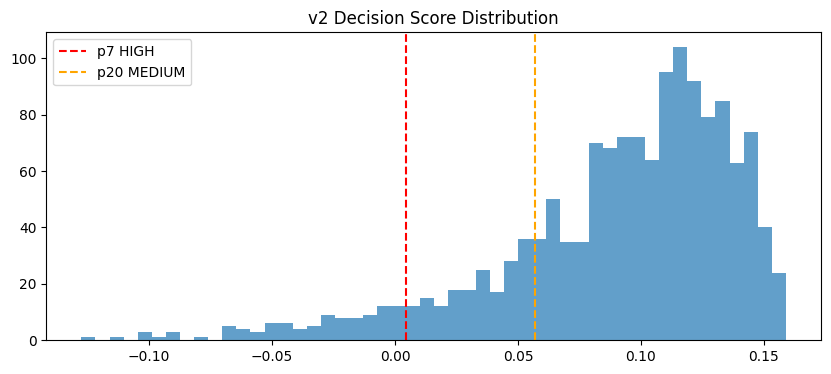

Done — download ml_artifacts_v2.zip from Files panel


In [52]:
val_scores  = model.decision_function(X_val)
test_scores = model.decision_function(X_test)

plt.figure(figsize=(10, 4))
plt.hist(val_scores, bins=50, alpha=0.7)
plt.axvline(np.percentile(val_scores, 7),  color='red',    linestyle='--', label='p7 HIGH')
plt.axvline(np.percentile(val_scores, 20), color='orange', linestyle='--', label='p20 MEDIUM')
plt.legend(); plt.title("v2 Decision Score Distribution"); plt.show()

HIGH_THRESHOLD   = float(np.percentile(val_scores, 7))
MEDIUM_THRESHOLD = float(np.percentile(val_scores, 20))

import os
os.makedirs("ml_artifacts_v2", exist_ok=True)

joblib.dump(model,  "ml_artifacts_v2/judge_anomaly_iforest_v2.joblib")
joblib.dump(scaler, "ml_artifacts_v2/robust_scaler_v2.joblib")

config = {
    "model_version": "judge-anomaly-iforest-v2",
    "score_scale": "0-5",
    "features": FEATURES,
    "features_removed_pending_instrumentation": [
        "review_duration_sec",
        "edit_count"
    ],
    "risk_thresholds": {
        "high":   HIGH_THRESHOLD,
        "medium": MEDIUM_THRESHOLD
    }
}
with open("ml_artifacts_v2/feature_config_v2.json", "w") as f:
    json.dump(config, f, indent=2)

import shutil
shutil.make_archive("ml_artifacts_v2", "zip", "ml_artifacts_v2")
print("Done — download ml_artifacts_v2.zip from Files panel")

In [27]:
# Diagnose: how different are anomalies from normal reviews?
test_df_diag = test_df.copy()
test_df_diag["decision_score"] = model.decision_function(X_test)

print("=== Feature means: Normal vs Anomaly ===")
cols = FEATURES + ["decision_score"]
comparison = test_df_diag.groupby("anomaly_label")[cols].mean().T
comparison.columns = ["normal", "anomaly"]
comparison["difference"] = (comparison["anomaly"] - comparison["normal"]).abs()
print(comparison.sort_values("difference", ascending=False).round(3))

print("\n=== Anomaly score distributions ===")
print("Normal reviews:")
print(test_df_diag[test_df_diag["anomaly_label"]==0]["decision_score"].describe().round(4))
print("\nActual anomalies:")
print(test_df_diag[test_df_diag["anomaly_label"]==1]["decision_score"].describe().round(4))

print("\n=== Missed anomalies (false negatives) — what do they look like? ===")
missed = test_df_diag[(test_df_diag["anomaly_label"]==1) & (test_df_diag["predicted_anomaly"]==0)]
print(missed[["overall_score","peer_abs_delta","judge_z_score","category_spread","decision_score"]].describe().round(3))

=== Feature means: Normal vs Anomaly ===
                          normal  anomaly  difference
judge_z_score           -999.426   -6.239     993.186
comment_word_count       135.131  125.768       9.363
project_z_score           -0.008   -3.290       3.282
peer_abs_delta             0.755    2.260       1.505
peer_delta                 0.035   -0.695       0.730
overall_score              3.153    2.471       0.682
decision_score             0.078    0.002       0.077
project_peer_std           0.644    0.716       0.072
judge_mean_before          3.147    3.095       0.052
project_peer_mean          3.118    3.166       0.049
category_spread            0.896    0.944       0.048
judge_std_before           0.738    0.764       0.026
rubric_completion_ratio    0.988    0.978       0.010
has_judge_history          0.750    0.754       0.004

=== Anomaly score distributions ===
Normal reviews:
count    1371.0000
mean        0.0785
std         0.0396
min        -0.0948
25%         0.0581
5

In [28]:
print("\n=== False alarm rate by judge type ===")
normal_only = test_df_diag[test_df_diag["anomaly_label"] == 0]
print(
    normal_only.groupby("judge_type")["predicted_anomaly"]
    .agg(["sum","count","mean"])
    .rename(columns={"sum":"false_alarms","count":"total","mean":"rate"})
    .round(3)
)


=== False alarm rate by judge type ===
              false_alarms  total   rate
judge_type                              
generous                19    261  0.073
inconsistent             7    140  0.050
normal                  23    748  0.031
strict                  16    222  0.072


In [40]:
test_df_diag = test_df.copy()
test_df_diag["decision_score"] = model.decision_function(X_test)
test_df_diag["predicted_anomaly"] = pred

# What do the CAUGHT anomalies look like vs MISSED ones?
caught = test_df_diag[(test_df_diag["anomaly_label"]==1) & (test_df_diag["predicted_anomaly"]==1)]
missed = test_df_diag[(test_df_diag["anomaly_label"]==1) & (test_df_diag["predicted_anomaly"]==0)]

print("=== Caught anomalies ===")
print(caught[["overall_score","peer_abs_delta","project_z_score","judge_z_score"]].describe().round(3))

print("\n=== Missed anomalies ===")
print(missed[["overall_score","peer_abs_delta","project_z_score","judge_z_score"]].describe().round(3))

print("\n=== False alarm table ===")
normal_only = test_df_diag[test_df_diag["anomaly_label"] == 0]
print(
    normal_only.groupby("judge_type")["predicted_anomaly"]
    .agg(["sum","count","mean"])
    .rename(columns={"sum":"false_alarms","count":"total","mean":"rate"})
    .round(3)
)

=== Caught anomalies ===
       overall_score  peer_abs_delta  project_z_score  judge_z_score
count         40.000          40.000           40.000         40.000
mean           1.591           2.803           -6.497         -1.402
std            2.028           0.728           11.188          2.707
min            0.000           0.749          -52.769         -5.000
25%            0.056           2.386           -9.115         -3.732
50%            0.562           2.777           -4.939         -1.846
75%            2.643           3.297           -0.701          0.000
max            5.000           4.243            9.452          5.000

=== Missed anomalies ===
       overall_score  peer_abs_delta  project_z_score  judge_z_score
count         29.000          29.000           29.000         29.000
mean           3.685           1.510            1.132          1.089
std            1.967           0.479            2.428          2.504
min            0.000           0.324           -3.24